In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import shap

In [3]:
!rm -f /content/accepted_2007_to_2018Q4.csv.gz
!kaggle datasets download -d wordsforthewise/lending-club -p /content/ --unzip --force

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:59<00:00, 22.7MB/s]



In [4]:
df = pd.read_csv('/content/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv', low_memory= False, encoding='latin1')
print (df.shape)
print (df.head())

(2260701, 151)
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amoun

In [5]:
df = df.sample(n=300000, random_state=42).reset_index(drop=True)
print(df.shape)

(300000, 151)


In [6]:
for col in df.select_dtypes(include ='number').columns:
  df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna('Unknown')

In [7]:

df['has_derog'] = df['mths_since_last_major_derog'].notna().astype(int) if 'mths_since_last_major_derog' in df.columns else 0
df['has_revol_delinq'] = df['mths_since_recent_revol_delinq'].notna().astype(int) if 'mths_since_recent_revol_delinq' in df.columns else 0

/tmp/ipykernel_10294/2762073938.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_derog'] = df['mths_since_last_major_derog'].notna().astype(int) if 'mths_since_last_major_derog' in df.columns else 0
/tmp/ipykernel_10294/2762073938.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_revol_delinq'] = df['mths_since_recent_revol_delinq'].notna().astype(int) if 'mths_since_recent_revol_delinq' in df.columns else 0


In [8]:
threshold = len(df)* 0.4
df = df.dropna(thresh=threshold, axis=1)
print (df.shape)

(300000, 152)


In [9]:
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default', ] else 0
)
print(df['default'].value_counts())

default
0    264250
1     35750
Name: count, dtype: int64


/tmp/ipykernel_10294/859230562.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['default'] = df['loan_status'].apply(


In [10]:
df_original = df.copy()

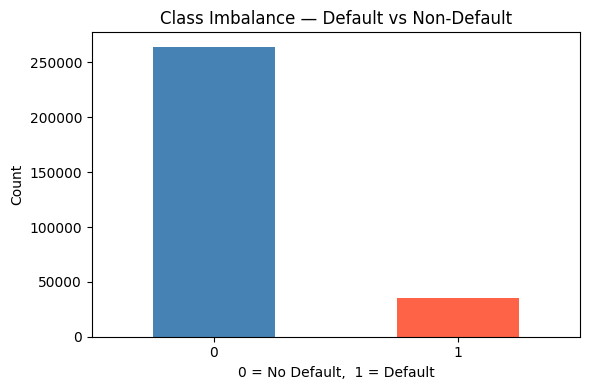

In [11]:
plt.figure(figsize=(6,4))
df_original['default'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Imbalance — Default vs Non-Default')
plt.xlabel('0 = No Default,  1 = Default')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10294/1393353823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y='default', data=df_plot,


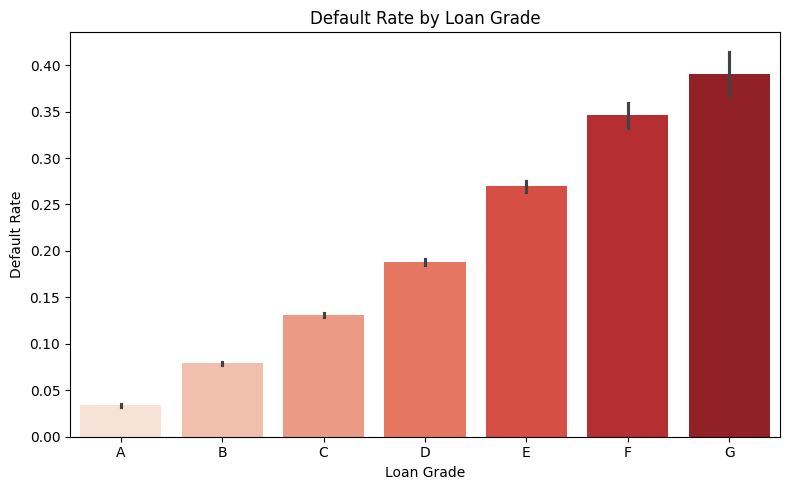

In [12]:
plt.figure(figsize=(8,5))
df_plot = df_original[df_original['grade'].isin(['A','B','C','D','E','F','G'])]
sns.barplot(x='grade', y='default', data=df_plot,
            order=['A','B','C','D','E','F','G'], palette='Reds')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10294/3777836353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='home_ownership', y='default', data=df_original, palette='Blues')


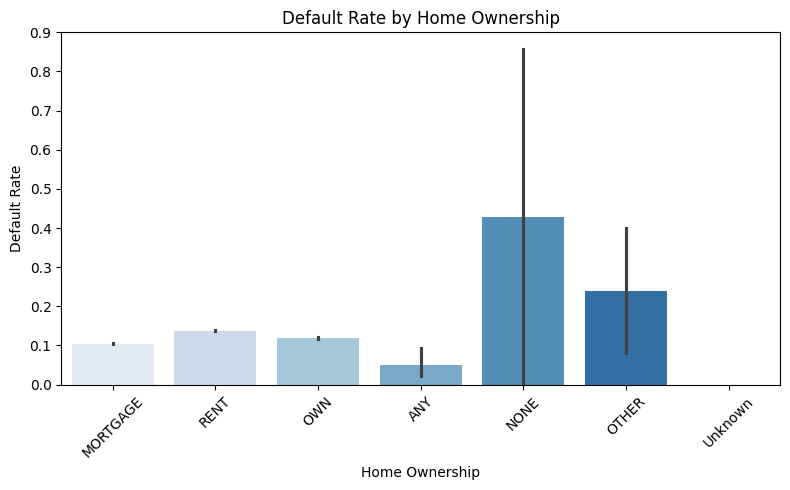

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='home_ownership', y='default', data=df_original, palette='Blues')
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

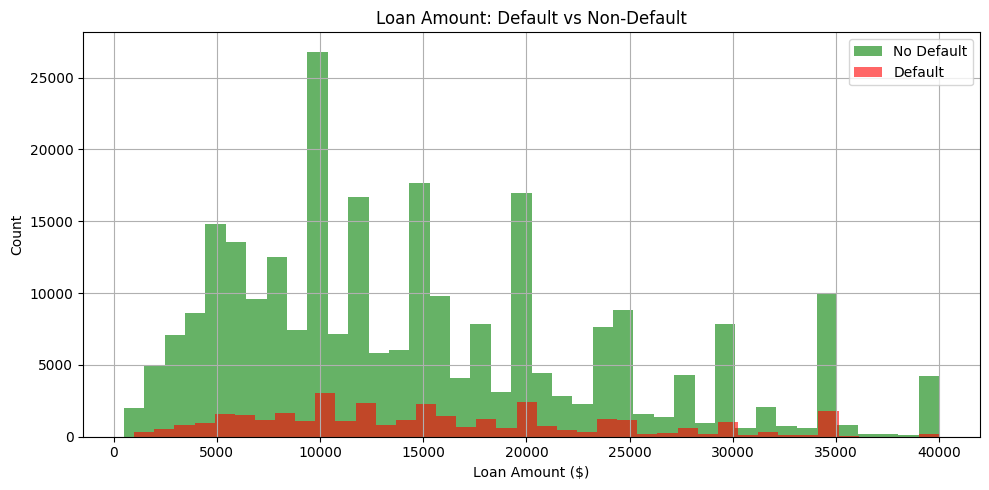

In [14]:
plt.figure(figsize=(10,5))
df_original[df_original['default']==0]['loan_amnt'].hist(
    alpha=0.6, bins=40, label='No Default', color='green')
df_original[df_original['default']==1]['loan_amnt'].hist(
    alpha=0.6, bins=40, label='Default', color='red')
plt.title('Loan Amount: Default vs Non-Default')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

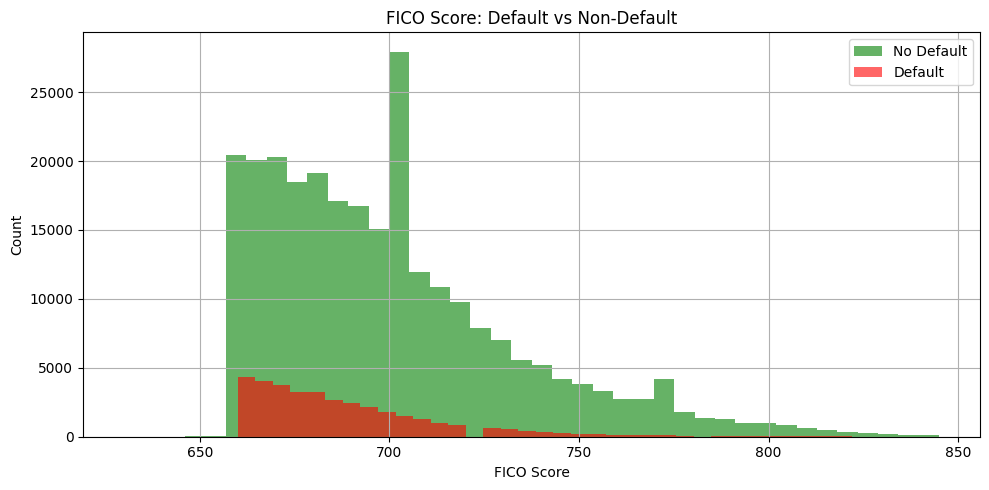

In [15]:
fico_col = 'fico_range_low' if 'fico_range_low' in df.columns else 'fico_range_high'

plt.figure(figsize=(10,5))
df_original[df_original['default']==0][fico_col].hist(
    alpha=0.6, bins=40, label='No Default', color='green')
df_original[df_original['default']==1][fico_col].hist(
    alpha=0.6, bins=40, label='Default', color='red')
plt.title('FICO Score: Default vs Non-Default')
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

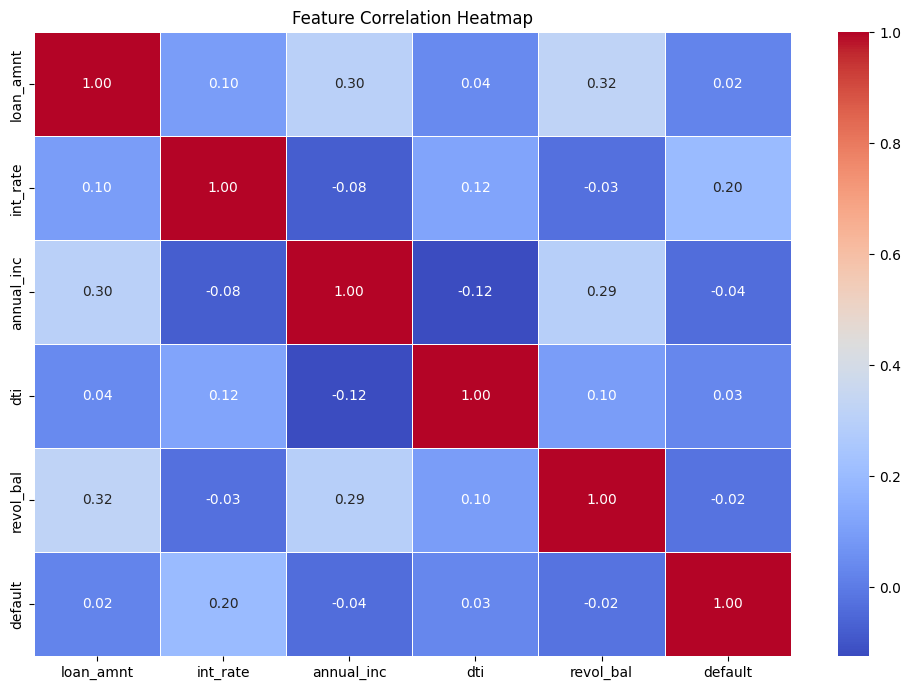

In [16]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'default']
num_cols = [c for c in num_cols if c in df_original.columns]

plt.figure(figsize=(10,7))
sns.heatmap(df_original[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [17]:
cols_to_encode = [c for c in ['grade','home_ownership','purpose'] if c in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print("Final shape after encoding:", df.shape)

Final shape after encoding: (300000, 177)


In [18]:

print('sub_grade' in df.columns)

if 'sub_grade' in df.columns:
    df = pd.get_dummies(df, columns=['sub_grade'], drop_first=True)
    print("sub_grade encoded, new shape:", df.shape)

True
sub_grade encoded, new shape: (300000, 211)


In [19]:
# NEW CELL
if 'term' in df.columns:
    df['term_60months'] = df['term'].apply(lambda x: 1 if '60' in str(x) else 0)
    print(df['term_60months'].value_counts())

term_60months
0    213523
1     86477
Name: count, dtype: int64


In [20]:
df['dti_custom'] = df['installment'] / (df['annual_inc'] / 12)
# installment = monthly payment, annual_inc/12 = monthly income

In [21]:
df['credit_util'] = df['revol_util'] / 100

In [22]:

df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
print(df['loan_to_income'])

0         0.266664
1         0.438336
2         0.048192
3         0.115863
4         0.384609
            ...   
299995    0.374991
299996    0.344276
299997    0.156249
299998    0.369225
299999    0.173911
Name: loan_to_income, Length: 300000, dtype: float64


In [23]:
df['has_derog'] = df['mths_since_last_major_derog'].apply(
    lambda x: 0 if pd.isnull(x) else 1
)


In [24]:
df['has_revol_delinq'] = df['mths_since_recent_revol_delinq'].apply(
    lambda x: 0 if pd.isnull(x) else 1
)

In [25]:
df['has_pub_rec'] = (df['pub_rec'] > 0).astype(int)

In [26]:
print(df[['loan_to_income', 'credit_util', 'has_derog',
          'has_revol_delinq', 'has_pub_rec']].describe())

       loan_to_income    credit_util  has_derog  has_revol_delinq  \
count   300000.000000  300000.000000   300000.0          300000.0   
mean        14.831481       0.503202        1.0               1.0   
std        603.244912       0.246843        0.0               0.0   
min          0.000171       0.000000        1.0               1.0   
25%          0.124998       0.315000        1.0               1.0   
50%          0.199997       0.502000        1.0               1.0   
75%          0.299206       0.693000        1.0               1.0   
max      40000.000000       1.910000        1.0               1.0   

         has_pub_rec  
count  300000.000000  
mean        0.158907  
std         0.365590  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


In [27]:
# REPLACES CELL 20
sub_grade_cols = [c for c in df.columns if c.startswith('sub_grade_')]

features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
            'fico_range_low', 'credit_util',
            'has_derog', 'has_revol_delinq', 'has_pub_rec',
            'open_acc', 'term_60months'] + sub_grade_cols

# Drop loan_to_income and revol_bal — they showed near-zero correlation earlier
features = [f for f in features if f in df.columns]
print("Using features:", features)

X = df[features]
y = df['default']
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Using features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'credit_util', 'has_derog', 'has_revol_delinq', 'has_pub_rec', 'open_acc', 'term_60months', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'sub_grade_Unknown']
X shape: (300000, 46)
y distribution:
 default
0    264250
1     35750
Name: count, dtype: int64


In [28]:
X = X.fillna(X.median())
print("Missing values in X:", X.isnull().sum().sum())

Missing values in X: 0


In [29]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (240000, 46)
Test size: (60000, 46)


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 211400, 1: 28600}
After SMOTE: {1: 211400, 0: 211400}


In [31]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
print("Done!")

Training Logistic Regression...
Done!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (takes 2-3 mins)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
print("Done!")

Training Random Forest (takes 2-3 mins)...
Done!


In [33]:
from xgboost import XGBClassifier

scale = (y_train==0).sum() / (y_train==1).sum()
print("scale_pos_weight:", scale)

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)   # NOTE: X_train, NOT X_train_bal
print("Done!")

scale_pos_weight: 7.391608391608392
Training XGBoost...
Done!


In [34]:
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp

print("="*50)
for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb_model)]:
    probs = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probs)

    pos_probs = probs[y_test == 1]
    neg_probs = probs[y_test == 0]
    ks = ks_2samp(pos_probs, neg_probs).statistic

    print(f"{name}")
    print(f"  AUC-ROC : {auc:.3f}")
    print(f"  KS Stat : {ks:.3f}")
    print("="*50)

Logistic Regression
  AUC-ROC : 0.588
  KS Stat : 0.158
Random Forest
  AUC-ROC : 0.701
  KS Stat : 0.299
XGBoost
  AUC-ROC : 0.738
  KS Stat : 0.356


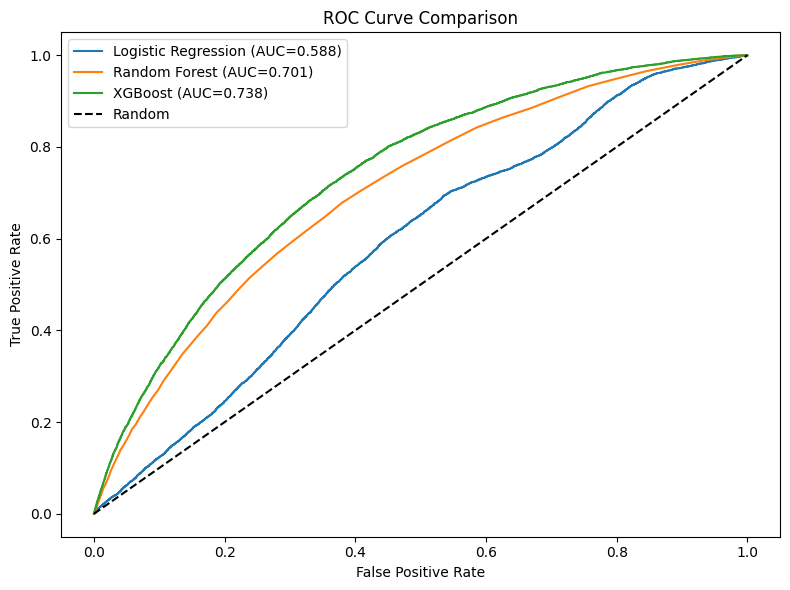

In [35]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb_model)]:
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
import pickle

with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Model saved!")

Model saved!


In [38]:
import shap

print("Creating SHAP explainer (takes a minute)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

with open('explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("Done!")

Creating SHAP explainer (takes a minute)...
Done!


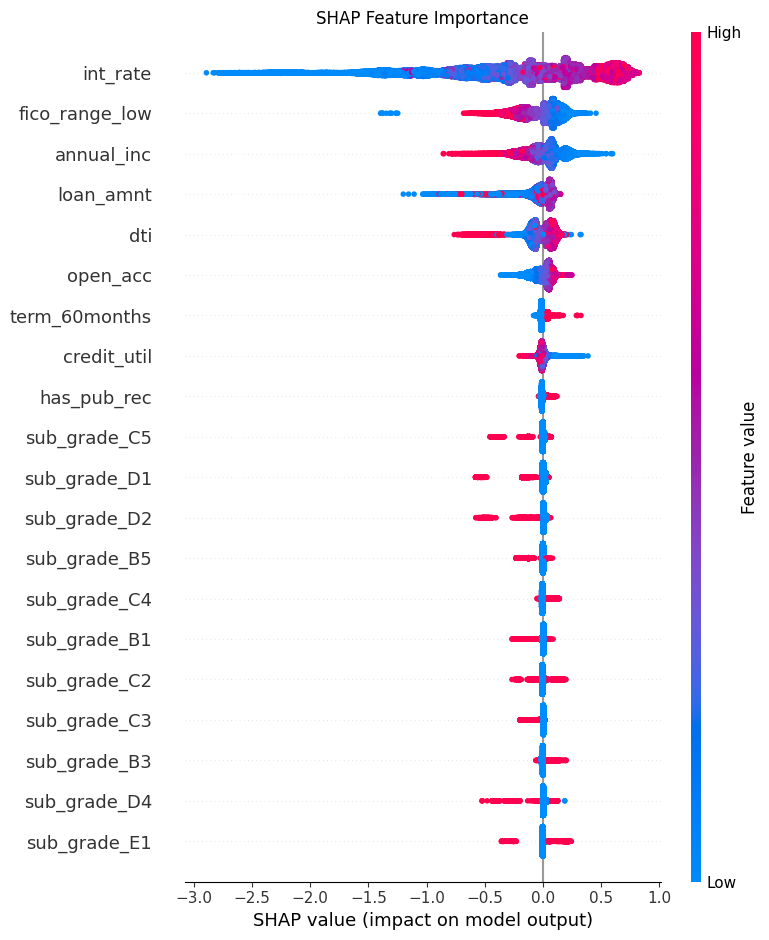

In [40]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

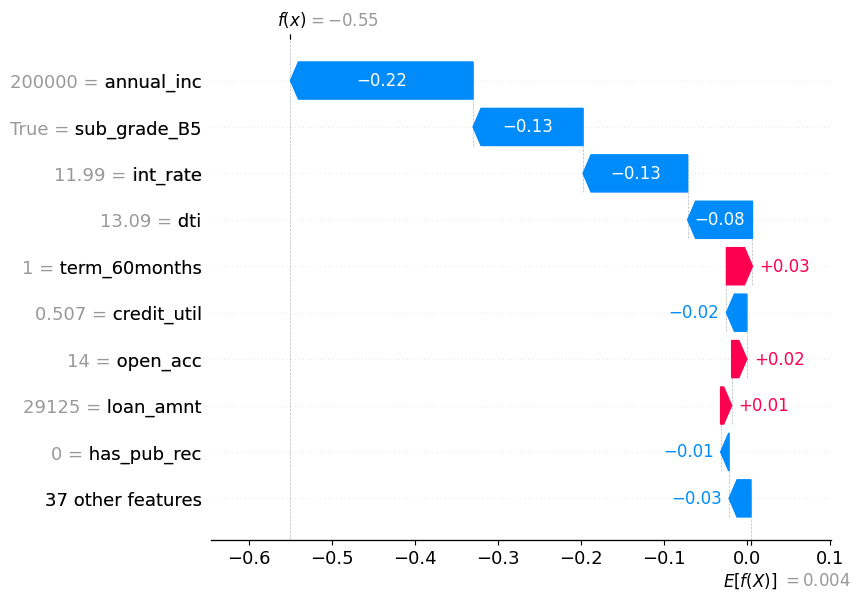

In [41]:
i = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i].values,
        feature_names=features
    )
)